# Layer 1; 32; 3x3; AvgPool

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/puneet6060/intel-image-classification


## Import Libraries

In [1]:
import os

import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.metrics import f1_score

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TF version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))
tf.test.is_built_with_cuda()

2026-05-12 15:26:12.823473: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778599573.241219      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778599573.355945      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778599574.476856      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778599574.476900      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778599574.476903      57 computation_placer.cc:177] computation placer alr

TF version: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


True

## Config

In [2]:
TRAIN_DIR  = '/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train'
VAL_DIR    = '/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test'
TEST_DIR   = '/kaggle/input/datasets/puneet6060/intel-image-classification/seg_pred/seg_pred'
MODEL_DIR = '/kaggle/working/models/cnn'
os.makedirs(MODEL_DIR, exist_ok=True)

IMG_SIZE    = (150, 150)
BATCH_SIZE  = 64
EPOCHS      = 10
NUM_CLASSES = 6
LR          = 1e-4
VAL_SPLIT   = 0.2

## Import Dataset

In [3]:
AUTOTUNE = tf.data.AUTOTUNE

normalization = keras.layers.Rescaling(1.0 / 255.0)

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True,
)
class_names = train_ds.class_names

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False,
)

train_ds = (
    train_ds
    .map(lambda x, y: (normalization(x), y), num_parallel_calls=AUTOTUNE)
    .cache()
    .shuffle(buffer_size=1000, seed=SEED, reshuffle_each_iteration=True)
    .prefetch(buffer_size=AUTOTUNE)
)

val_ds = (
    val_ds
    .map(lambda x, y: (normalization(x), y), num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

test_ds = (
    test_ds
    .map(lambda x, y: (normalization(x), y), num_parallel_calls=AUTOTUNE)
    .prefetch(buffer_size=AUTOTUNE)
)

train_count = sum(1 for _ in tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=VAL_SPLIT, subset="training",
    seed=SEED, image_size=IMG_SIZE, batch_size=1, label_mode="int"
))
val_count = sum(1 for _ in tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=VAL_SPLIT, subset="validation",
    seed=SEED, image_size=IMG_SIZE, batch_size=1, label_mode="int"
))
test_count = sum(1 for _ in tf.keras.utils.image_dataset_from_directory(
    VAL_DIR, image_size=IMG_SIZE, batch_size=1, label_mode="int", shuffle=False
))

print("Kelas      :", {name: i for i, name in enumerate(class_names)})
print(f"Train      : {train_count} gambar")
print(f"Validation : {val_count} gambar")
print(f"Test       : {test_count} gambar")

Found 14034 files belonging to 6 classes.
Using 11228 files for training.


I0000 00:00:1778599622.918438      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778599622.924446      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.
Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.
Kelas      : {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}
Train      : 11228 gambar
Validation : 2806 gambar
Test       : 3000 gambar


## CNN Model Baseline Architecture

In [34]:
MODEL_NAME = 'Layer-1-64-5x5-maxpool'
model = keras.Sequential([
    keras.layers.Input(shape=IMG_SIZE + (3,), name='input'),
    keras.layers.Conv2D(64, (5, 5), activation='relu', padding='valid', name='conv2s_1'),
    keras.layers.MaxPooling2D((2, 2), name='maxpool_1'),
    keras.layers.Flatten(name='flatten'),
    keras.layers.Dense(128, activation='relu', name='dense_1'),
    keras.layers.Dense(6, activation='softmax', name='output'),
], name=MODEL_NAME)
model.summary()

Model: "Layer-1-64-5x5-maxpool"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2s_1 (Conv2D)               │ (None, 146, 146, 64)   │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling2D)        │ (None, 73, 73, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 341056)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │    43,655,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,660,934 (166.55 MB)

 Trainable params: 43,660,934 (166.55 MB)

 Non-trainable params: 0 (0.00 B)

## Compilation and Training

In [35]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

callback = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=f'/kaggle/working/models/cnn/{MODEL_NAME}.h5',
        monitor='val_loss', save_best_only=True, verbose=1
    ),
]

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callback,
    verbose=1
)

Epoch 1/10
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.4705 - loss: 1.5126
Epoch 1: val_loss improved from inf to 0.62087, saving model to /kaggle/working/models/cnn/Layer-1-64-5x5-maxpool.h5


176/176 ━━━━━━━━━━━━━━━━━━━━ 15s 73ms/step - accuracy: 0.4716 - loss: 1.5087 - val_accuracy: 0.7919 - val_loss: 0.6209
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7059 - loss: 0.8339
Epoch 2: val_loss did not improve from 0.62087
176/176 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - accuracy: 0.7059 - loss: 0.8338 - val_accuracy: 0.7306 - val_loss: 0.6759
Epoch 3/10
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7533 - loss: 0.7074
Epoch 3: val_loss improved from 0.62087 to 0.44887, saving model to /kaggle/working/models/cnn/Layer-1-64-5x5-maxpool.h5


176/176 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.7534 - loss: 0.7072 - val_accuracy: 0.8610 - val_loss: 0.4489
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8035 - loss: 0.6022
Epoch 4: val_loss did not improve from 0.44887
176/176 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - accuracy: 0.8035 - loss: 0.6021 - val_accuracy: 0.8660 - val_loss: 0.4643
Epoch 5/10
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8375 - loss: 0.5191
Epoch 5: val_loss improved from 0.44887 to 0.44002, saving model to /kaggle/working/models/cnn/Layer-1-64-5x5-maxpool.h5


176/176 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.8374 - loss: 0.5193 - val_accuracy: 0.8767 - val_loss: 0.4400
Epoch 6/10
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8591 - loss: 0.4708
Epoch 6: val_loss did not improve from 0.44002
176/176 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - accuracy: 0.8591 - loss: 0.4708 - val_accuracy: 0.7876 - val_loss: 0.6256
Epoch 7/10
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8809 - loss: 0.4022
Epoch 7: val_loss improved from 0.44002 to 0.37283, saving model to /kaggle/working/models/cnn/Layer-1-64-5x5-maxpool.h5


176/176 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.8809 - loss: 0.4023 - val_accuracy: 0.8963 - val_loss: 0.3728
Epoch 8/10
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9042 - loss: 0.3620
Epoch 8: val_loss improved from 0.37283 to 0.31407, saving model to /kaggle/working/models/cnn/Layer-1-64-5x5-maxpool.h5


176/176 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.9042 - loss: 0.3619 - val_accuracy: 0.9041 - val_loss: 0.3141
Epoch 9/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9203 - loss: 0.3196
Epoch 9: val_loss improved from 0.31407 to 0.28425, saving model to /kaggle/working/models/cnn/Layer-1-64-5x5-maxpool.h5


176/176 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.9203 - loss: 0.3196 - val_accuracy: 0.9323 - val_loss: 0.2842
Epoch 10/10
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9311 - loss: 0.2803
Epoch 10: val_loss improved from 0.28425 to 0.20567, saving model to /kaggle/working/models/cnn/Layer-1-64-5x5-maxpool.h5


176/176 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.9310 - loss: 0.2804 - val_accuracy: 0.9512 - val_loss: 0.2057
Restoring model weights from the end of the best epoch: 10.


## Evaluation

In [36]:
y_pred_proba = model.predict(test_ds)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.concatenate([y.numpy() for _, y in test_ds])

macro_f1 = f1_score(y_true, y_pred, average='macro')
print(f"Macro F1 Score: {macro_f1:.4f}")

47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step
Macro F1 Score: 0.7699


## Plot

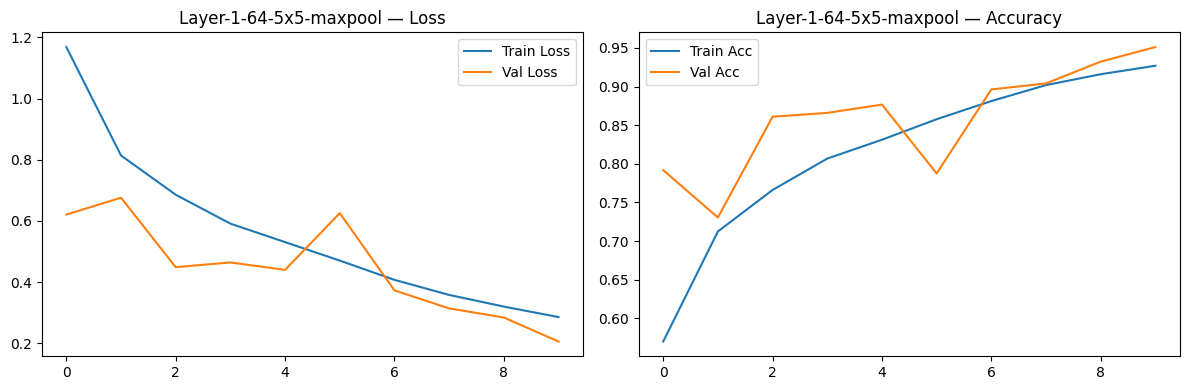

In [37]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['loss'],         label='Train Loss')
ax1.plot(history.history['val_loss'],     label='Val Loss')
ax1.set_title(f'{MODEL_NAME} — Loss'); ax1.legend()
ax2.plot(history.history['accuracy'],     label='Train Acc')
ax2.plot(history.history['val_accuracy'], label='Val Acc')
ax2.set_title(f'{MODEL_NAME} — Accuracy'); ax2.legend()
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, f'{MODEL_NAME}_curve.png'), dpi=100)
plt.show()